In [21]:
import slmcontrol
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform
from cameras.ImagingSourceNew import ImagingSourceCamera
from cameras.Ximea import XimeaCamera
from scipy.linalg import polar
from phase_screens import fourier_phase_screen
from augmented_gs import augmented_gs, fidelity
import jax
import jax.numpy as jnp
from utils import set_phase_reference, crop_center
from scipy.linalg import norm, inv

In [7]:
def remove_background(img, bg):
    return np.where(img > bg, img - bg, 0)

In [3]:
slm = slmcontrol.SLMDisplay(host="localhost")
_xs = np.arange(slm.width // 2) - slm.width//4
_ys = np.arange(slm.height) - slm.height//2
xs, ys = np.meshgrid(_xs, _ys)

In [8]:
camera_direct = ImagingSourceCamera()

In [4]:
camera_reciprocal = XimeaCamera()

In [9]:
holo = np.zeros((slm.height, slm.width), dtype=np.uint8)
slm.updateArray(holo)
bg_direct = camera_direct.capture().mean()
bg_reciprocal = camera_reciprocal.capture().mean()

In [5]:
with h5py.File("calibration/calibration.h5") as f:
    A_direct = f["A_direct"][:]
    t_direct = f["t_direct"][:]
    A_reciprocal = f["A_reciprocal"][:]
    t_reciprocal = f["t_reciprocal"][:]

u_direct, p_direct = polar(A_direct)
u_reciprocal, p_reciprocal = polar(A_reciprocal)

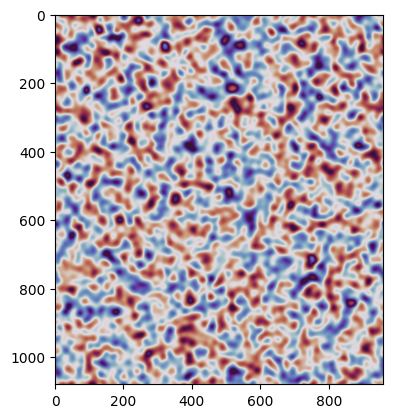

In [6]:
amplitude = 2**26
sigma = 0.5 / 2 / np.pi

phase_mask = fourier_phase_screen(slm.height, slm.width // 2, amplitude=amplitude, sigma=sigma)
phase_transformation = np.exp(1j * phase_mask)
rotated_phase_transformation = affine_transform(phase_transformation, u_direct)

plt.imshow(phase_mask, cmap="twilight")

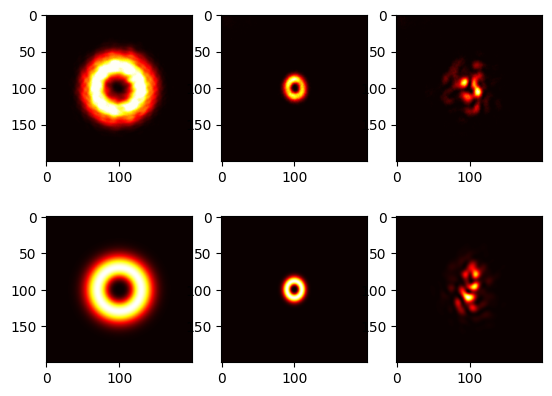

In [29]:
mode = slmcontrol.lg(xs, ys, p=0, l=-2, w=30)

rotated_phase_transformation = affine_transform(phase_transformation, np.flip(inv(u_direct), axis=0))

two_pi_modulation = 192

holo_mode = slmcontrol.generate_hologram(mode, two_pi_modulation, -3, 19)
holo_fourier = slmcontrol.generate_hologram(np.ones_like(mode), two_pi_modulation, -3, 19)
holo_phase_fourier = slmcontrol.generate_hologram(rotated_phase_transformation, two_pi_modulation, -3, 19)

holo1 = np.concatenate([holo_fourier, holo_mode], axis=1)
holo2 = np.concatenate([holo_phase_fourier, holo_mode], axis=1)

slm.updateArray(holo2)

camera_direct.set_exposure(100)
camera_reciprocal.set_exposure(100)


slm.updateArray(holo1)
image_direct = np.flip(camera_direct.capture(), axis=0)
image_fourier = np.flip(camera_reciprocal.capture(), axis=0)
slm.updateArray(holo2)
image_phase_fourier = np.flip(camera_reciprocal.capture(), axis=0)

bg_direct = 2
bg_reciprocal = 5

image_direct = remove_background(image_direct, bg_direct)
image_fourier = remove_background(image_fourier, bg_reciprocal)
image_phase_fourier = remove_background(image_phase_fourier, bg_reciprocal)

corrected_image_direct = affine_transform(image_direct, A_direct, t_direct, mode.shape)
corrected_image_fourier = affine_transform(image_fourier, A_reciprocal, t_reciprocal, mode.shape)
corrected_image_phase_fourier = affine_transform(image_phase_fourier, A_reciprocal, t_reciprocal, mode.shape)

image_direct_theory = np.abs(mode)**2
image_fourier_theory = np.abs(np.fft.fftshift(np.fft.fft2(mode)))**2
image_phase_fourier_theory = np.abs(np.fft.fftshift(np.fft.fft2(mode * phase_transformation)))**2

fig, axs = plt.subplots(2, 3, )

axs[0, 0].imshow(crop_center(corrected_image_direct, 200), cmap="hot")
axs[0, 1].imshow(crop_center(corrected_image_fourier, 200), cmap="hot")
axs[0, 2].imshow(crop_center(corrected_image_phase_fourier, 200), cmap="hot")

axs[1, 0].imshow(crop_center(image_direct_theory, 200), cmap="hot")
axs[1, 1].imshow(crop_center(image_fourier_theory, 200), cmap="hot")
axs[1, 2].imshow(crop_center(image_phase_fourier_theory, 200), cmap="hot")


plt.show()

In [30]:
fidelity(jnp.complex64(jnp.sqrt(image_phase_fourier_theory)), jnp.complex64(jnp.sqrt(corrected_image_phase_fourier)))

Array(0.59617144, dtype=float32)